# 06 More models: decision tree, KNN, and a neural network
Do other types of models predict dropout better than logistic regression? Same data, same split, same features (after semester 1).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score

df = pd.read_csv('../data/data.csv', sep=';')
df.columns = df.columns.str.strip()
df['dropout'] = (df['Target'] == 'Dropout').astype(int)

CATEGORICAL = ['Marital status', 'Application mode', 'Course', 'Previous qualification',
               'Nacionality', "Mother's qualification", "Father's qualification",
               "Mother's occupation", "Father's occupation"]
SEM1 = [c for c in df.columns if c.startswith('Curricular units 1st sem')]
SEM2 = [c for c in df.columns if c.startswith('Curricular units 2nd sem')]
features = [c for c in df.columns if c not in ['Target', 'dropout'] + SEM1 + SEM2] + SEM1

X_train, X_test, y_train, y_test = train_test_split(
    df[features], df['dropout'], test_size=0.2, stratify=df['dropout'], random_state=42)

cats = [c for c in features if c in CATEGORICAL]
nums = [c for c in features if c not in CATEGORICAL]
prep = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cats),
    ('num', StandardScaler(), nums)])
X_train_t = prep.fit_transform(X_train)
X_test_t = prep.transform(X_test)
print(X_train_t.shape)

(3539, 229)


**Notes:** Same data, split, and features as notebook 02. This time I prepare the data once (`fit_transform` on training data, `transform` on test data) so every model uses the exact same inputs. One-hot encoding turns the 30 original columns into 229 number columns.

In [2]:
def scores(name, prob, cutoff=0.5):
    pred = (prob >= cutoff).astype(int)
    return {'model': name,
            'accuracy': round(accuracy_score(y_test, pred), 3),
            'recall': round(recall_score(y_test, pred), 3),
            'precision': round(precision_score(y_test, pred), 3),
            'roc_auc': round(roc_auc_score(y_test, prob), 3)}

**Notes:** The same 4 scores as notebook 02, at the default cutoff of 0.5, so the comparison is fair.

In [3]:
rows = []
models = {
    'Logistic regression': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'Random forest': RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                            class_weight='balanced', random_state=42),
    'Decision tree': DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42),
    'KNN (k=15)': KNeighborsClassifier(n_neighbors=15),
}
for name, model in models.items():
    model.fit(X_train_t, y_train)
    rows.append(scores(name, model.predict_proba(X_test_t)[:, 1]))
pd.DataFrame(rows)

,model,accuracy,recall,precision,roc_auc
0,Logistic regression,0.860,0.806,0.768,0.913
1,Random forest,0.837,0.782,0.730,0.900
2,Decision tree,0.827,0.803,0.702,0.867
3,KNN (k=15),0.821,0.514,0.880,0.855


**Takeaway:** The decision tree catches almost as many dropouts as logistic regression (recall 0.803), but it's less precise (0.702) and ranks students less well (AUC 0.867). KNN is the opposite: very precise (0.880) but it misses about half of dropouts (recall 0.514). That's because KNN has no class weighting, so the larger "not dropout" group wins most votes. For an early warning tool, missing half of dropouts isn't acceptable.

In [4]:
import keras
from keras import layers

keras.utils.set_random_seed(42)

nn = keras.Sequential([
    layers.Input(shape=(X_train_t.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid'),
])
nn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

weights = {0: 1.0, 1: float((y_train == 0).sum() / (y_train == 1).sum())}
stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = nn.fit(X_train_t, y_train.values, validation_split=0.2, epochs=200, batch_size=32,
                 class_weight=weights, callbacks=[stop], verbose=0)
print('Epochs trained:', len(history.history['loss']))

rows.append(scores('Neural network', nn.predict(X_test_t, verbose=0).ravel()))
results = pd.DataFrame(rows)
results

Epochs trained: 23


,model,accuracy,recall,precision,roc_auc
0,Logistic regression,0.860,0.806,0.768,0.913
1,Random forest,0.837,0.782,0.730,0.900
2,Decision tree,0.827,0.803,0.702,0.867
3,KNN (k=15),0.821,0.514,0.880,0.855
4,Neural network,0.855,0.739,0.795,0.907


**Takeaway:** The neural network scores close to logistic regression (AUC 0.907 vs. 0.913) and is more precise (0.795 vs. 0.768), but it catches fewer dropouts (recall 0.739 vs. 0.806). A more complex model didn't beat the simple one here. With about 3,500 training students and clear signals like semester 1 courses passed, logistic regression already captures most of the pattern, and it's much easier to explain to advisors.

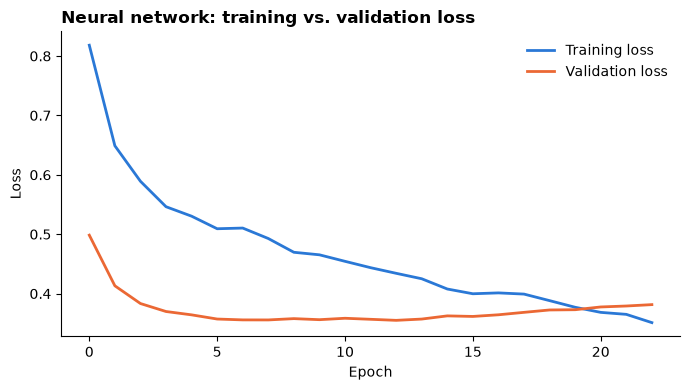

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.history['loss'], color='#2a78d6', linewidth=2, label='Training loss')
ax.plot(history.history['val_loss'], color='#eb6834', linewidth=2, label='Validation loss')
ax.set_title('Neural network: training vs. validation loss', loc='left', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig('../charts/11_nn_loss.png', dpi=150)
plt.show()

**Takeaway:** Training loss keeps falling, but validation loss stops improving around epoch 10 to 12 and then slowly rises. That's the start of **overfitting**: the network is learning details of the training students that don't carry over to new ones. Early stopping caught this and kept the best version. (Training loss starts higher because it's measured with dropout turned on and with dropouts weighted about 2x.)

## Summary
I compared 5 models on the same data:

| Model | Recall | Precision | ROC AUC |
|---|---|---|---|
| Logistic regression | 0.806 | 0.768 | 0.913 |
| Random forest | [yours] | [yours] | [yours] |
| Decision tree | 0.803 | 0.702 | 0.867 |
| KNN (k=15) | 0.514 | 0.880 | 0.855 |
| Neural network | [yours] | [yours] | [yours] |

Logistic regression is still the best choice: highest AUC, strong recall, and the easiest to explain. The neural network was close but not better, and its loss curve showed overfitting after about 10 epochs. **Lesson: a more complex model isn't automatically a better one.** For this data size and problem, simple and explainable wins.